In [1]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [3]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace = True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace = True)

df.isnull().sum()

C:\Users\samsu\AppData\Local\Temp\ipykernel_33140\1953466294.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace = True)
C:\Users\samsu\AppData\Local\Temp\ipykernel_33140\1953466294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [4]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [5]:
df['person_home_ownership'] = df['person_home_ownership'].map({'RENT':0, 'OWN':1, 'MORTGAGE':2, 'OTHER':3})
df['loan_intent'] = df['loan_intent'].map({'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2, 'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5})
df['loan_grade'] = df['loan_grade'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6})
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

In [6]:
# Decisions tree - One person deciding alone

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

A = df.drop('loan_status', axis = 1)
B = df['loan_status']

A_train, A_test, B_train, B_test = train_test_split(A, B, test_size = 0.2)

model = DecisionTreeClassifier()
model.fit(A_train, B_train)

print(model.score(A_test, B_test))

0.8815405861592758


In [1]:
# Random Forest - 100 people deciding and voting

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Features and target
A = df.drop('loan_status', axis = 1)
B = df['loan_status']

A_train, A_test, B_train, B_test = train_test_split(A, B, test_size = 0.2)

model = RandomForestClassifier()
model.fit(A_train, B_train)

print(model.score(A_test, B_test))

NameError: name 'df' is not defined

Matplotlib is building the font cache; this may take a moment.


<Axes: >

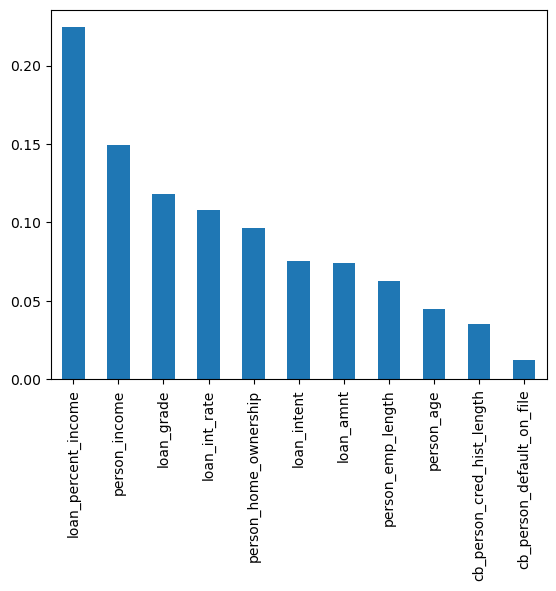

In [13]:
# On basis of this model, one can tell a money lender to not lend money to an individual and the next question will be - 'WHY?'. Here's why
# FEATURE IMPORTANCE

import pandas as pd

importance = pd.Series(model.feature_importances_, index=A.columns)
importance.sort_values(ascending=False).plot(kind='bar')